In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

df = pd.read_csv('../data/diabetes_cleaned.csv')

# Set the style for all charts
plt.style.use('seaborn-v0_8')
print("Ready!")

Ready!


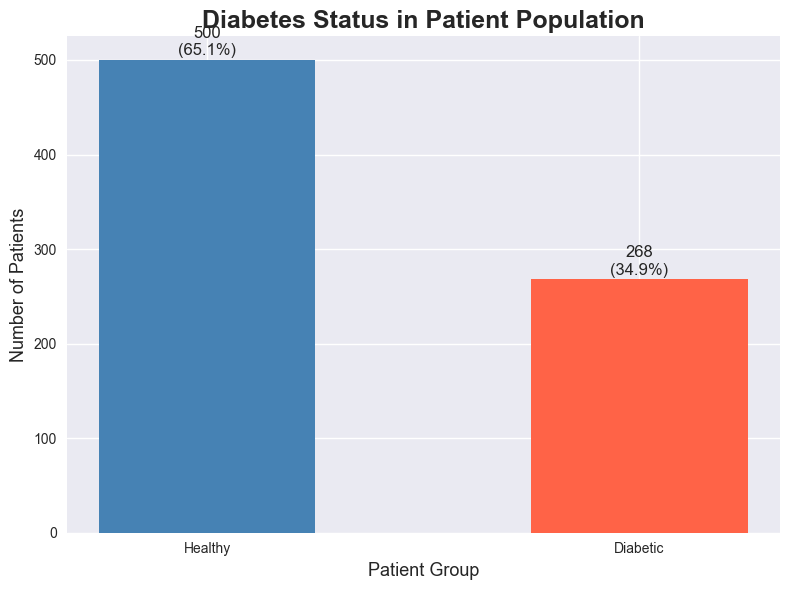

In [2]:
fig, ax = plt.subplots(figsize=(8, 6))

counts = df['Outcome'].value_counts()
bars = ax.bar(['Healthy', 'Diabetic'], counts.values, color=['steelblue', 'tomato'], width=0.5)

# Add percentage labels on top of each bar
for bar, count in zip(bars, counts.values):
    percentage = count / len(df) * 100
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 5,
            f'{count}\n({percentage:.1f}%)', ha='center', fontsize=12)

ax.set_title('Diabetes Status in Patient Population', fontsize=18, fontweight='bold')
ax.set_xlabel('Patient Group', fontsize=13)
ax.set_ylabel('Number of Patients', fontsize=13)

plt.tight_layout()
plt.savefig('../outputs/charts/01_outcome_distribution.png', dpi=150, bbox_inches='tight')
plt.show()

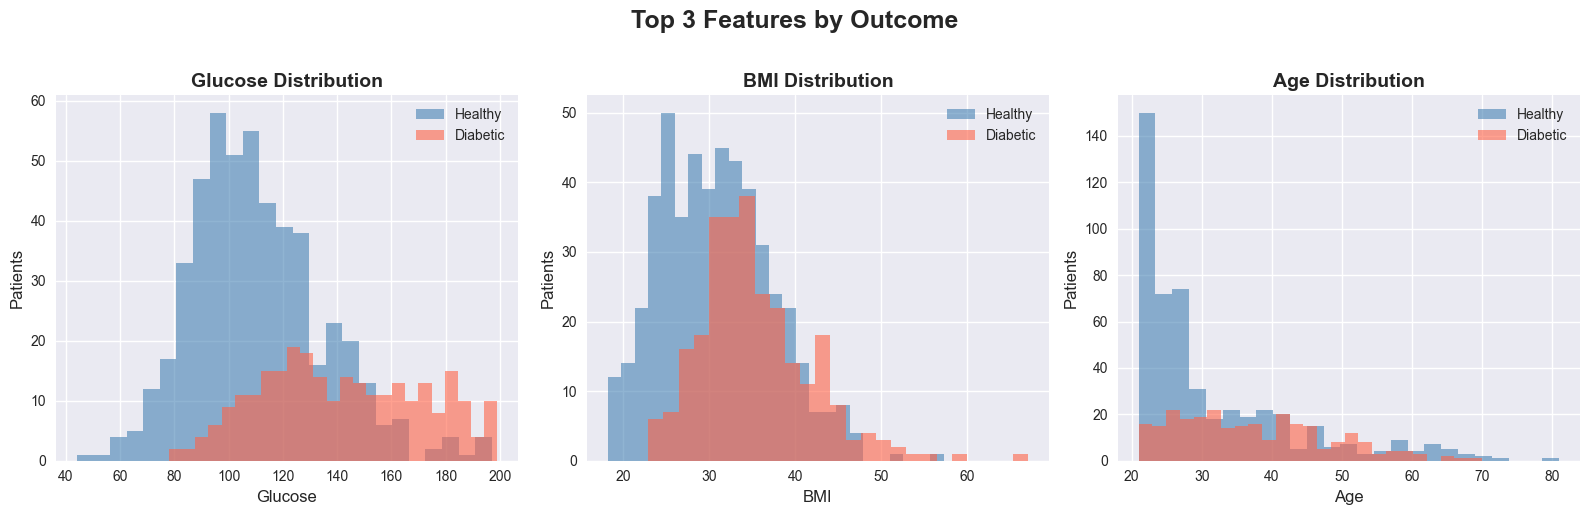

In [3]:
fig, axes = plt.subplots(1, 3, figsize=(16, 5))

features = ['Glucose', 'BMI', 'Age']
colors_healthy = 'steelblue'
colors_diabetic = 'tomato'

for i, feature in enumerate(features):
    healthy = df[df['Outcome'] == 0][feature]
    diabetic = df[df['Outcome'] == 1][feature]
    
    axes[i].hist(healthy, alpha=0.6, label='Healthy', color=colors_healthy, bins=25)
    axes[i].hist(diabetic, alpha=0.6, label='Diabetic', color=colors_diabetic, bins=25)
    axes[i].set_title(f'{feature} Distribution', fontsize=14, fontweight='bold')
    axes[i].set_xlabel(feature, fontsize=12)
    axes[i].set_ylabel('Patients', fontsize=12)
    axes[i].legend()

plt.suptitle('Top 3 Features by Outcome', fontsize=18, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('../outputs/charts/02_distributions.png', dpi=150, bbox_inches='tight')
plt.show()

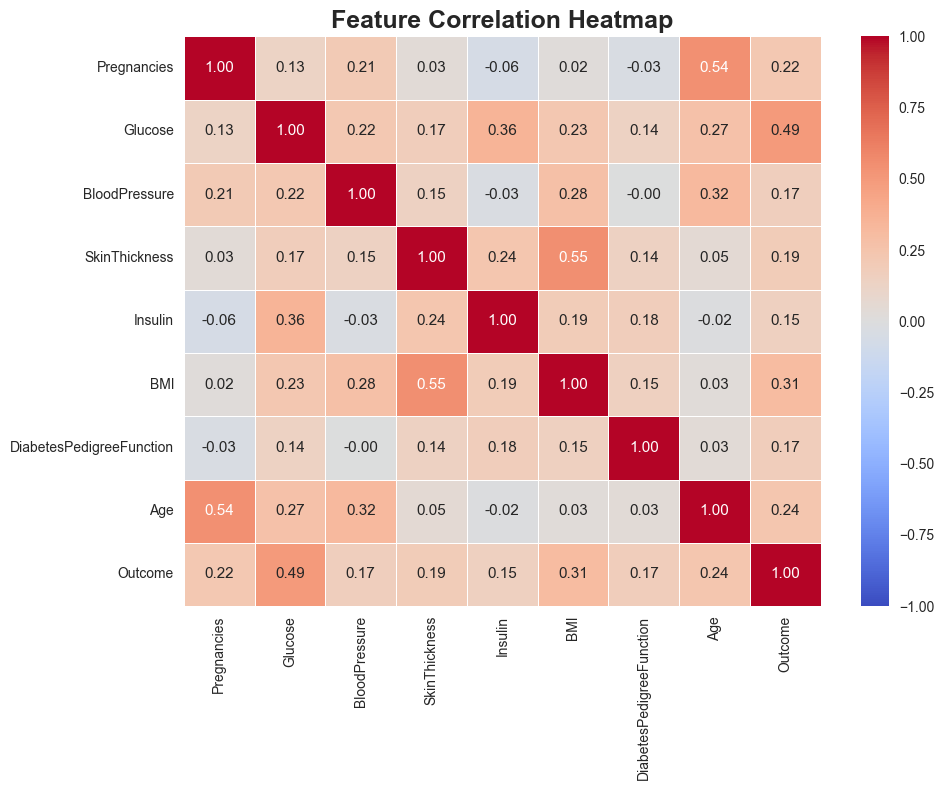

In [4]:
corr = df.corr()

plt.figure(figsize=(10, 8))
sns.heatmap(corr, 
            annot=True, 
            fmt='.2f', 
            cmap='coolwarm',
            linewidths=0.5,
            annot_kws={'size': 11},
            vmin=-1, vmax=1)

plt.title('Feature Correlation Heatmap', fontsize=18, fontweight='bold')
plt.tight_layout()
plt.savefig('../outputs/charts/03_heatmap.png', dpi=150, bbox_inches='tight')
plt.show()

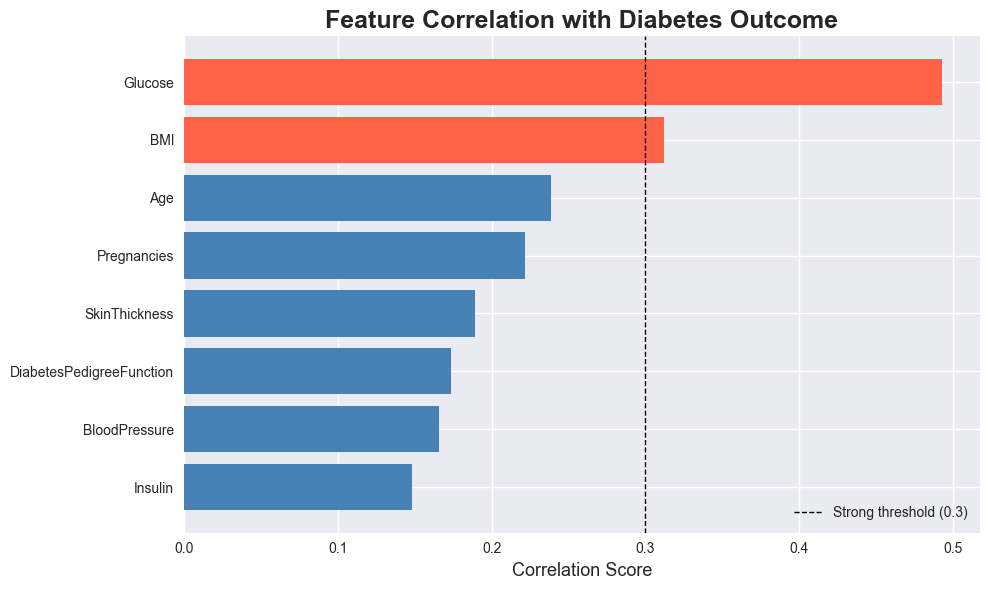

In [5]:
outcome_corr = corr['Outcome'].drop('Outcome').sort_values()

colors = ['tomato' if x > 0.3 else 'steelblue' for x in outcome_corr.values]

plt.figure(figsize=(10, 6))
bars = plt.barh(outcome_corr.index, outcome_corr.values, color=colors)

plt.title('Feature Correlation with Diabetes Outcome', fontsize=18, fontweight='bold')
plt.xlabel('Correlation Score', fontsize=13)
plt.axvline(x=0.3, color='black', linewidth=1, linestyle='--', label='Strong threshold (0.3)')
plt.legend()
plt.tight_layout()
plt.savefig('../outputs/charts/04_feature_importance.png', dpi=150, bbox_inches='tight')
plt.show()

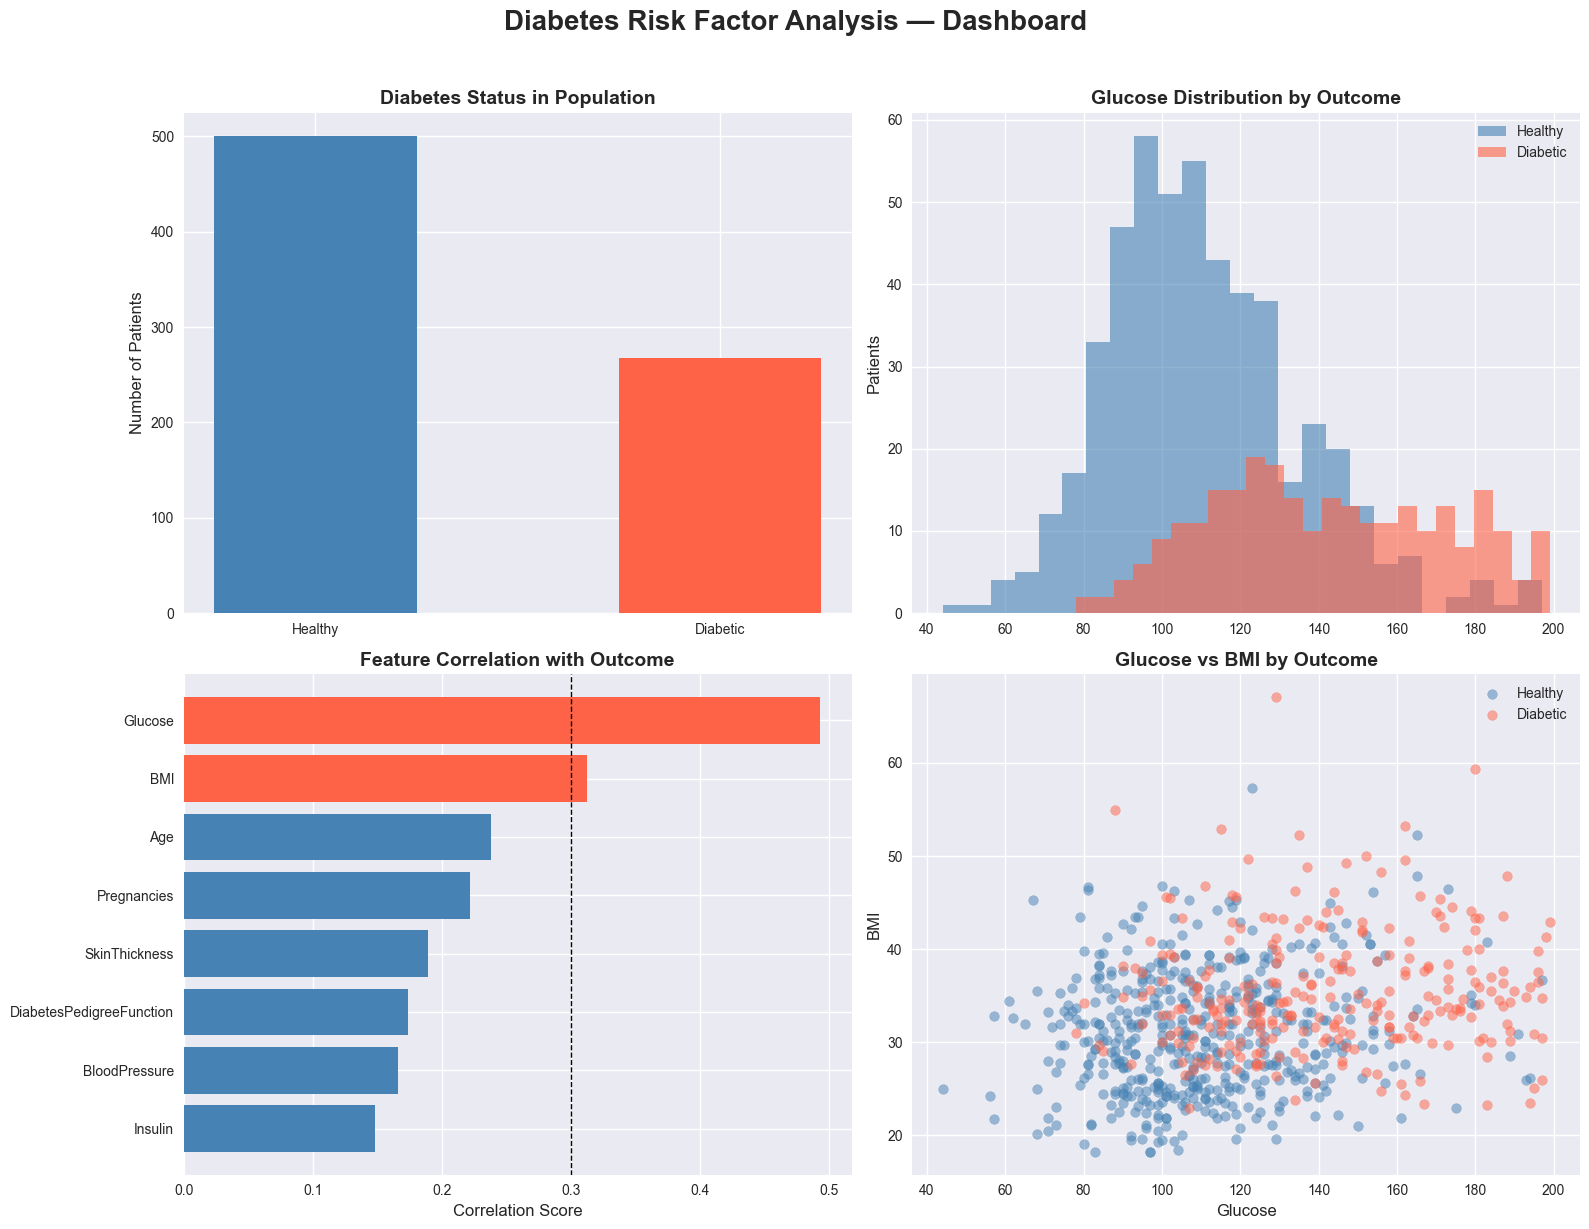

In [6]:
fig, axes = plt.subplots(2, 2, figsize=(16, 12))

# Chart 1 - Outcome Distribution
counts = df['Outcome'].value_counts()
axes[0, 0].bar(['Healthy', 'Diabetic'], counts.values, color=['steelblue', 'tomato'], width=0.5)
axes[0, 0].set_title('Diabetes Status in Population', fontsize=14, fontweight='bold')
axes[0, 0].set_ylabel('Number of Patients', fontsize=12)

# Chart 2 - Glucose Distribution
healthy = df[df['Outcome'] == 0]
diabetic = df[df['Outcome'] == 1]
axes[0, 1].hist(healthy['Glucose'], alpha=0.6, label='Healthy', color='steelblue', bins=25)
axes[0, 1].hist(diabetic['Glucose'], alpha=0.6, label='Diabetic', color='tomato', bins=25)
axes[0, 1].set_title('Glucose Distribution by Outcome', fontsize=14, fontweight='bold')
axes[0, 1].set_ylabel('Patients', fontsize=12)
axes[0, 1].legend()

# Chart 3 - Feature Importance
outcome_corr = corr['Outcome'].drop('Outcome').sort_values()
colors = ['tomato' if x > 0.3 else 'steelblue' for x in outcome_corr.values]
axes[1, 0].barh(outcome_corr.index, outcome_corr.values, color=colors)
axes[1, 0].set_title('Feature Correlation with Outcome', fontsize=14, fontweight='bold')
axes[1, 0].set_xlabel('Correlation Score', fontsize=12)
axes[1, 0].axvline(x=0.3, color='black', linewidth=1, linestyle='--')

# Chart 4 - Glucose vs BMI Scatter
axes[1, 1].scatter(healthy['Glucose'], healthy['BMI'], alpha=0.5, label='Healthy', color='steelblue')
axes[1, 1].scatter(diabetic['Glucose'], diabetic['BMI'], alpha=0.5, label='Diabetic', color='tomato')
axes[1, 1].set_title('Glucose vs BMI by Outcome', fontsize=14, fontweight='bold')
axes[1, 1].set_xlabel('Glucose', fontsize=12)
axes[1, 1].set_ylabel('BMI', fontsize=12)
axes[1, 1].legend()

plt.suptitle('Diabetes Risk Factor Analysis — Dashboard', fontsize=20, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('../outputs/charts/05_dashboard.png', dpi=150, bbox_inches='tight')
plt.show()